<a href="https://colab.research.google.com/github/monteiro-sara/AD-RIDDLE_2024/blob/main/AD_RIDDLE_Hierarchical_clustering_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Data handling and scientific computing
import pandas as pd
import numpy as np
from scipy import stats

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score

# Statistical Modeling
import statsmodels.api as sm

# Miscellaneous
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

###
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# import dataset
df = pd.read_excel('/content/test_dataset_adriddle.xlsx')
print("Dataset imported successfully.")

Dataset imported successfully.


In [ ]:
# Step 1: Quick check of the data
print("Quick check of the data:")
print(df.head())

# Step 2: Check data types and non-null counts
df_cleaned = df.copy()  # Assuming df_cleaned is a cleaned version of df
info_df = pd.DataFrame({
    'Feature': df_cleaned.columns,
    'Data Type': df_cleaned.dtypes,
    'Non-Null Count': df_cleaned.notnull().sum()
}).reset_index(drop=True)

# Display dataset information
print("\nDataset Information:")
print(info_df.to_string(index=False))  # Displaying without index for better formatting

# Step 3: Descriptive statistics for numerical variables
# Select only numerical columns
numerical_df = df_cleaned.select_dtypes(include=['number'])

# Calculate summary statistics
summary_stats = numerical_df.describe().transpose()

# Calculate variance for numerical columns and add it to the summary table
summary_stats['variance'] = numerical_df.var()

# Display the summary statistics as a table
print("\nSummary Statistics Table:")
print(summary_stats.to_string())  # Displaying without index for better formatting

Quick check of the data:
   participant_id  age sex  edu_years diagnosis AD_biomarker_diagnosis  \
0            3462   64   F       12.0        AD         Preclinical AD   
1            3510   63   F       16.0        AD         Preclinical AD   
2            9717   65   M       16.0   Control                Control   
3            3985   66   F       17.0   Control                Control   
4            2841   59   F       14.0   Control                Control   

   mmse_moca  apoe4_carrier  csf_ab42  csf_ab40  csf_ab42_40_ratio  \
0        NaN            1.0    1080.0     22.09              0.049   
1        NaN            1.0     398.1     14.67              0.027   
2       30.0            0.0    2500.0     24.85              0.101   
3       29.0            0.0    2500.0     31.69              0.079   
4       29.0            0.0    1148.0     15.28              0.075   

   csf_ab42_40_abnormal  csf_ptau181  csf_ptau181_abnormal  csf_nfl  \
0                   1.0        19.26  

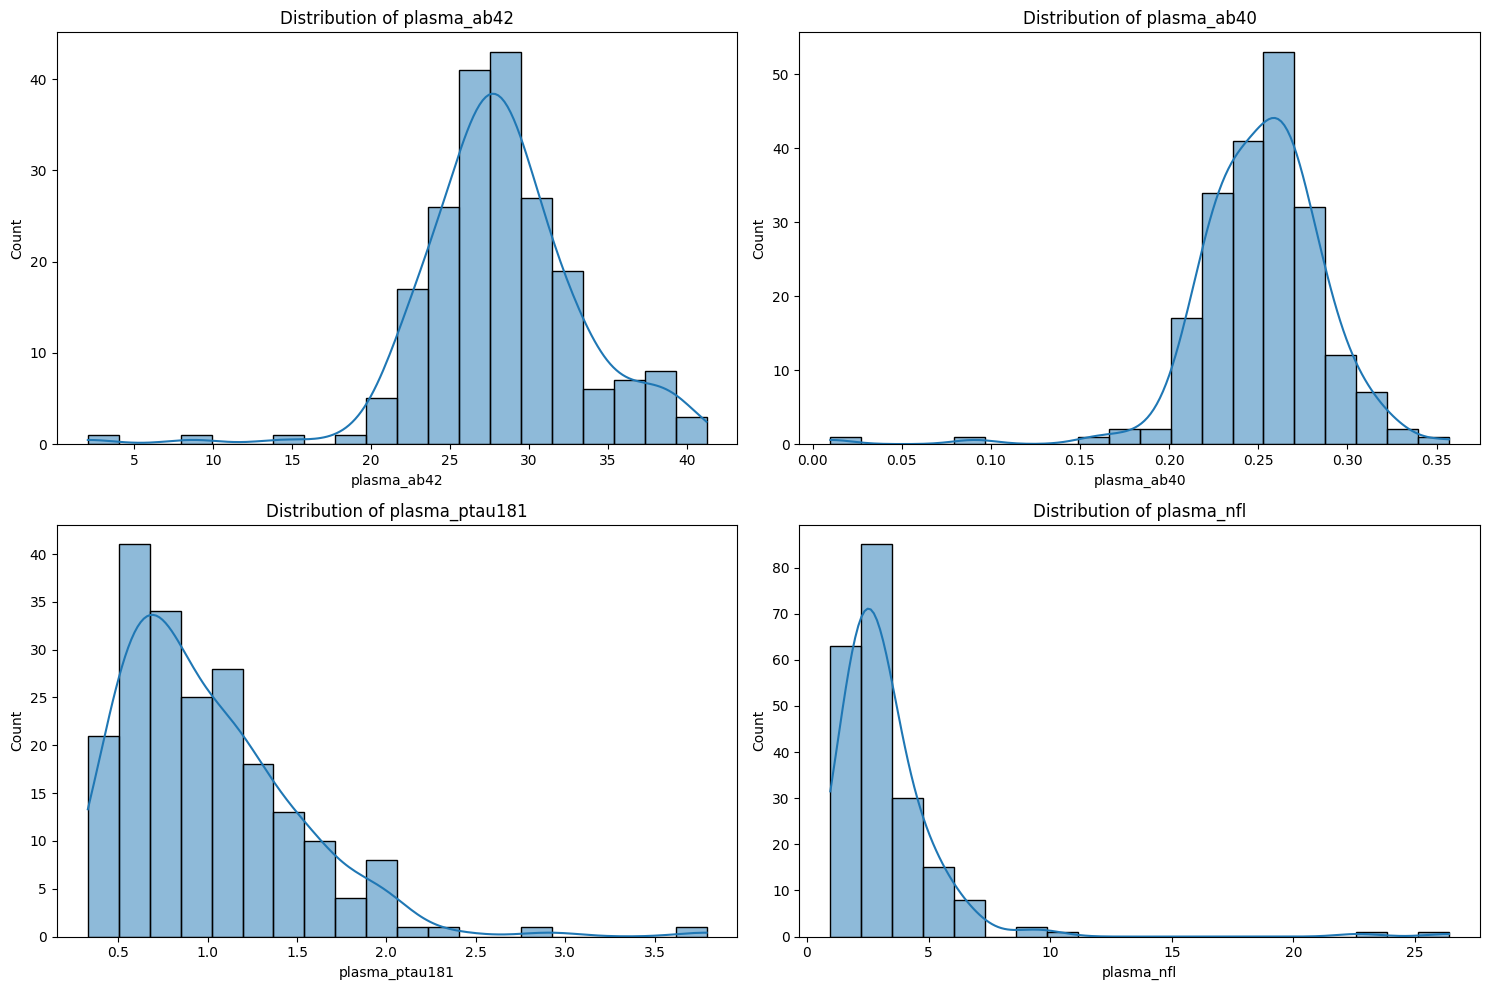

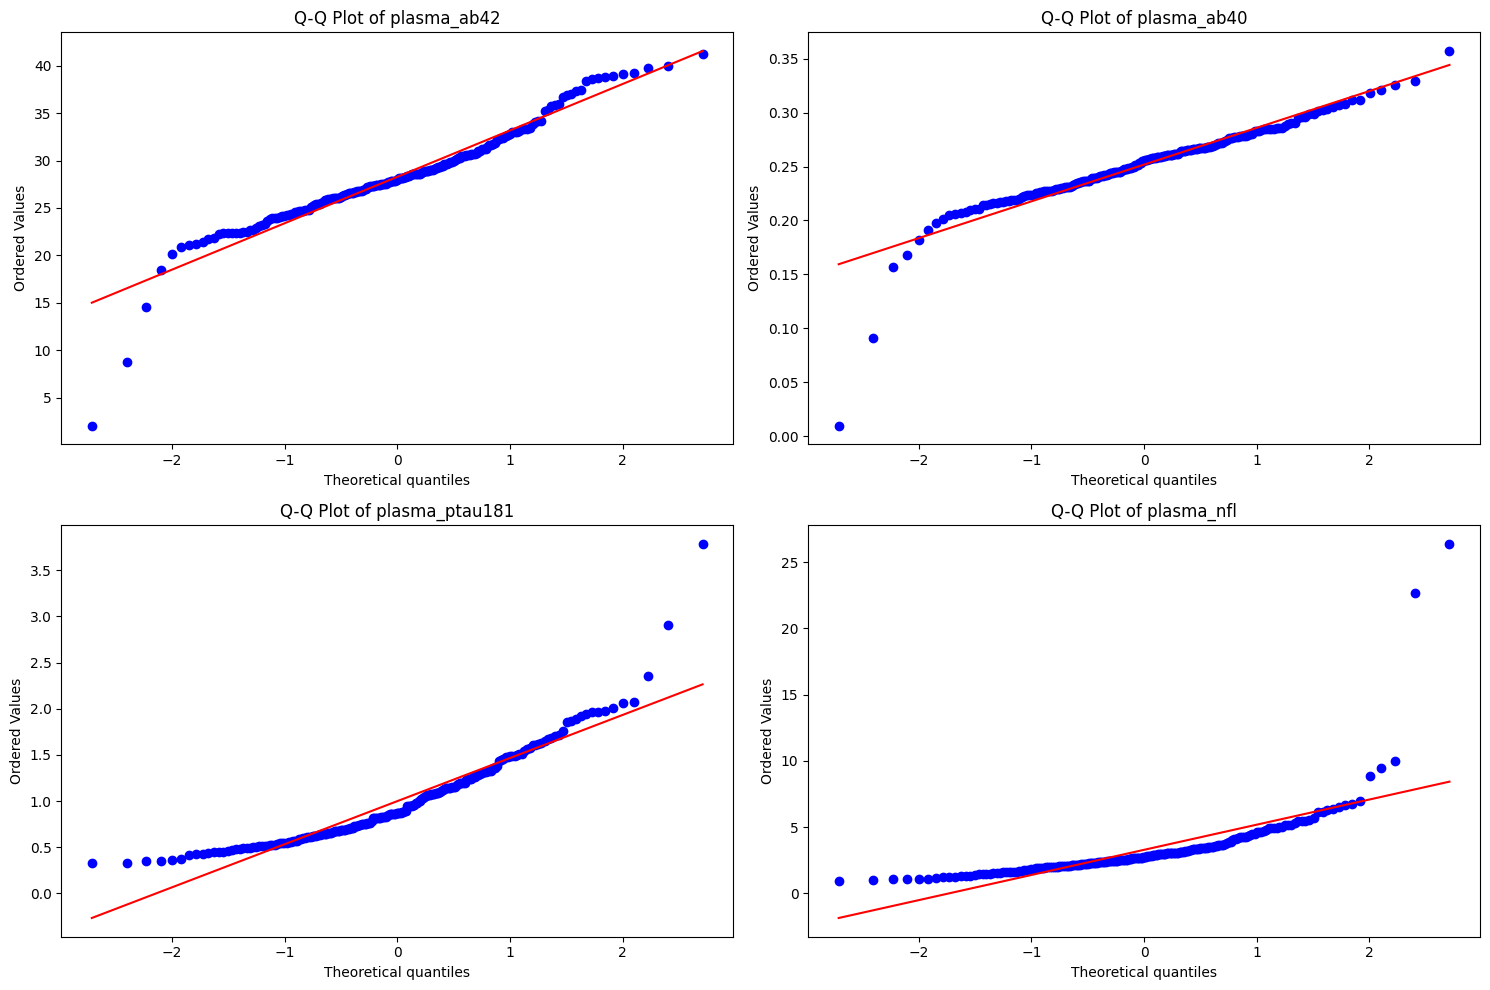

In [ ]:
# Step 1: Visualize the distribution with histograms
plt.figure(figsize=(15, 10))

# Loop through each plasma biomarker and plot its distribution
for i, col in enumerate(['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl']):
    plt.subplot(2, 2, i+1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

# Step 2: Q-Q Plots for Normality Check
plt.figure(figsize=(15, 10))

# Loop through each plasma biomarker and plot Q-Q plot
for i, col in enumerate(['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl']):
    plt.subplot(2, 2, i+1)
    stats.probplot(df[col].dropna(), dist="norm", plot=plt)
    plt.title(f"Q-Q Plot of {col}")

plt.tight_layout()
plt.show()

In [ ]:
# Shapiro-Wilk Test
from scipy.stats import shapiro

for col in ['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl']:
    stat, p_value = shapiro(df[col].dropna())
    print(f"Shapiro-Wilk Test for {col}:")
    print(f"  Test Statistic: {stat:.4f}, p-value: {p_value:.4f}")
    if p_value > 0.05:
        print(f"  {col} is likely normally distributed (fail to reject H0)\n")
    else:
        print(f"  {col} is not normally distributed (reject H0)\n")

# Kolmogorov-Smirnov Test
from scipy.stats import kstest

for col in ['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl']:
    stat, p_value = kstest(df[col].dropna(), 'norm')
    print(f"Kolmogorov-Smirnov Test for {col}:")
    print(f"  Test Statistic: {stat:.4f}, p-value: {p_value:.4f}")
    if p_value > 0.05:
        print(f"  {col} is likely normally distributed (fail to reject H0)\n")
    else:
        print(f"  {col} is not normally distributed (reject H0)\n")


Shapiro-Wilk Test for plasma_ab42:
  Test Statistic: 0.9383, p-value: 0.0000
  plasma_ab42 is not normally distributed (reject H0)

Shapiro-Wilk Test for plasma_ab40:
  Test Statistic: 0.8866, p-value: 0.0000
  plasma_ab40 is not normally distributed (reject H0)

Shapiro-Wilk Test for plasma_ptau181:
  Test Statistic: 0.8882, p-value: 0.0000
  plasma_ptau181 is not normally distributed (reject H0)

Shapiro-Wilk Test for plasma_nfl:
  Test Statistic: 0.5380, p-value: 0.0000
  plasma_nfl is not normally distributed (reject H0)

Kolmogorov-Smirnov Test for plasma_ab42:
  Test Statistic: 0.9951, p-value: 0.0000
  plasma_ab42 is not normally distributed (reject H0)

Kolmogorov-Smirnov Test for plasma_ab40:
  Test Statistic: 0.5528, p-value: 0.0000
  plasma_ab40 is not normally distributed (reject H0)

Kolmogorov-Smirnov Test for plasma_ptau181:
  Test Statistic: 0.6300, p-value: 0.0000
  plasma_ptau181 is not normally distributed (reject H0)

Kolmogorov-Smirnov Test for plasma_nfl:
  Test S

In [ ]:
# 1. Handling Missing Values - Imputation for All Variables
imputer = SimpleImputer(strategy='mean')
df_imputed = df.copy()

# List of columns to impute (all numerical columns, excluding categorical for now)
columns_to_impute = ['mmse_moca', 'csf_ab42', 'csf_ab40', 'csf_ab42_40_ratio', 'csf_ptau181',
                     'csf_nfl', 'plasma_ab42', 'plasma_ab40', 'plasma_ab42_40_ratio', 'plasma_ptau181', 'plasma_nfl']

df_imputed[columns_to_impute] = imputer.fit_transform(df_imputed[columns_to_impute])

# 2. Handle NaN in Categorical Column 'apoe4_carrier'
# For simplicity, we can fill NaN with a default value (0) if it makes sense in your context
df_imputed['apoe4_carrier'].fillna(0, inplace=True)  # Filling NaN with 0 or you can use mode/other

# 3. Encoding Categorical Variables ('sex' and 'apoe4_carrier')
df_imputed['sex'] = df_imputed['sex'].map({'M': 1, 'F': 0})
df_imputed['apoe4_carrier'] = df_imputed['apoe4_carrier'].astype(int)  # Now this conversion will work

# 4. Dropping irrelevant columns ('participant_id', 'diagnosis', 'AD_biomarker_diagnosis')
df_cluster = df_imputed.drop(['participant_id', 'diagnosis', 'AD_biomarker_diagnosis'], axis=1)

# 5. Standardizing the Data
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_cluster), columns=df_cluster.columns)

# Display the standardized data
df_scaled.head()

,age,sex,edu_years,mmse_moca,apoe4_carrier,csf_ab42,csf_ab40,csf_ab42_40_ratio,csf_ab42_40_abnormal,csf_ptau181,csf_ptau181_abnormal,csf_nfl,plasma_ab42,plasma_ab40,plasma_ab42_40_ratio,plasma_ptau181,plasma_nfl
0,-0.399639,-1.133893,-0.364723,0.000000,1.009662,0.940768,1.363947,0.236988,0.616441,-0.447932,-0.877058,-0.657068,-0.196366,-0.356804,0.046426,-0.542474,-0.880806
1,-0.511366,-1.133893,0.792329,0.000000,1.009662,-0.670690,-0.133380,-0.916051,0.616441,0.381206,1.140175,-0.363460,-0.200373,-0.133564,-0.185421,-0.290914,-0.492654
2,-0.287912,0.881917,0.792329,0.995133,-0.990430,4.296493,1.920904,2.962355,-1.622214,-0.226725,-0.877058,-0.289763,-0.551009,-0.747473,-0.011536,-0.266372,-0.442194
3,-0.176185,-1.133893,1.081592,0.726752,-0.990430,4.296493,3.301189,1.809315,-1.622214,-0.037230,1.140175,-0.536795,1.542788,-0.049850,1.785277,-0.992417,-0.535351
4,-0.958274,-1.133893,0.213803,0.726752,-0.990430,1.101464,-0.010285,1.599672,-1.622214,-1.072106,-0.877058,-0.722334,-5.253538,-6.747037,5.378904,0.310374,-0.484891


In [ ]:
# IQR method to detect outliers (does not assume normality)
Q1 = df[columns_to_impute].quantile(0.25)  # First quartile (25th percentile)
Q3 = df[columns_to_impute].quantile(0.75)  # Third quartile (75th percentile)
IQR = Q3 - Q1  # Interquartile Range

# Detect outliers
outliers = ((df[columns_to_impute] < (Q1 - 1.5 * IQR)) | (df[columns_to_impute] > (Q3 + 1.5 * IQR))).any(axis=1)

# Remove outliers
df_cleaned = df[~outliers]

# Check size of cleaned dataset
print(f"Dataset size after IQR-based outlier removal: {df_cleaned.shape}")

Dataset size after IQR-based outlier removal: (142, 20)


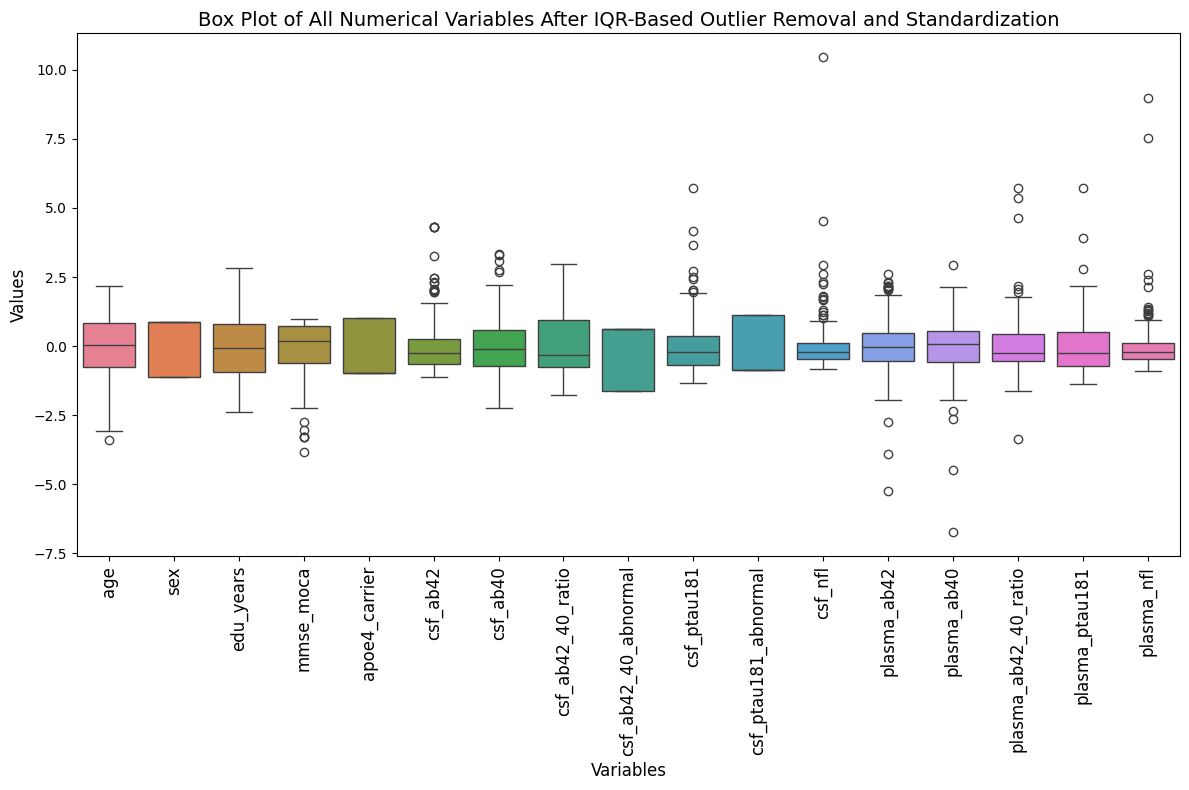

In [ ]:
# Proceed with the rest of the steps if data remains after IQR outlier removal
if df_scaled.shape[0] == 0:
    print("No data left after outlier removal.")
else:
    # Select numerical columns and proceed to box plot as before
    numerical_df = df_scaled.select_dtypes(include=['number'])

    if numerical_df.empty:
        print("No numerical columns left after outlier removal.")
    else:
        # Melt the DataFrame and plot the boxplot
        numerical_df_melted = numerical_df.melt(var_name='Variable', value_name='Value')

        # Create the boxplot with enhanced styling and color palette
        plt.figure(figsize=(12, 8))
        sns.boxplot(x='Variable', y='Value', data=numerical_df_melted, palette="husl")  # Use 'Set2' color palette

        # Customize the plot for better aesthetics
        plt.xticks(rotation=90, fontsize=12)  # Rotate x-axis labels for readability
        plt.title('Box Plot of All Numerical Variables After IQR-Based Outlier Removal and Standardization', fontsize=14)
        plt.ylabel('Values', fontsize=12)
        plt.xlabel('Variables', fontsize=12)

        # Set tighter layout for better space utilization
        plt.tight_layout()

        # Display the plot
        plt.show()

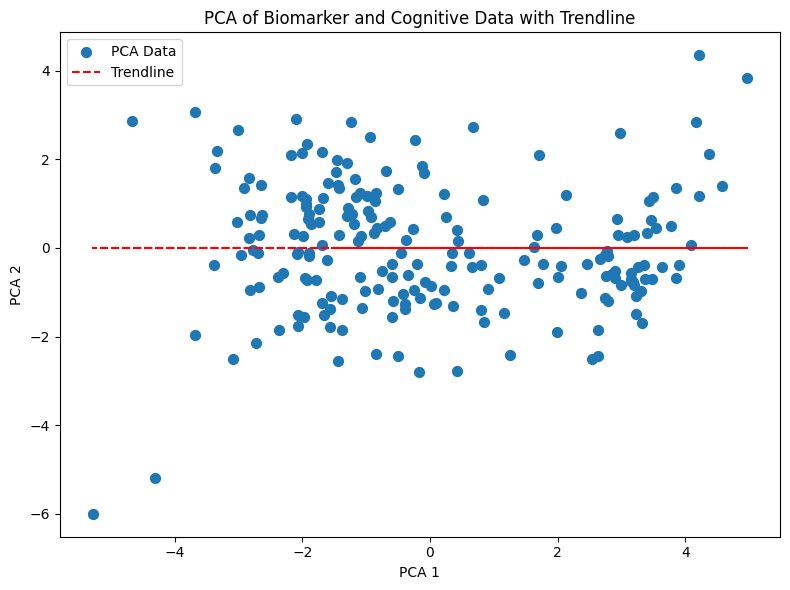

Silhouette Score: 0.495


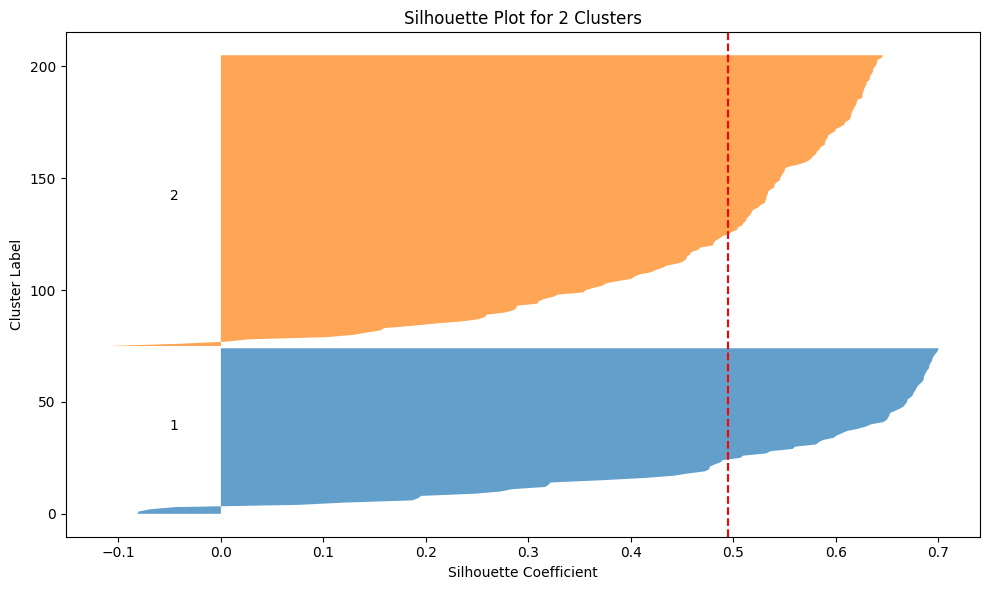

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Impute missing values (if there are any remaining NaNs in df_scaled)
imputer = SimpleImputer(strategy='mean')  # You can change to 'median' if preferred
df_scaled_imputed = pd.DataFrame(imputer.fit_transform(df_scaled), columns=df_scaled.columns)

# Step 2: Apply PCA on the imputed dataset
pca = PCA(n_components=2)  # Use 2 components for visualization
df_pca = pca.fit_transform(df_scaled_clean)

# Step 3: Plot the PCA result with a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], s=50, label='PCA Data')

# Step 4: Fit a linear trendline using numpy's polyfit
z = np.polyfit(df_pca[:, 0], df_pca[:, 1], 1)
p = np.poly1d(z)

# Plot the trendline on top of the scatter plot
plt.plot(df_pca[:, 0], p(df_pca[:, 0]), "r--", label='Trendline')

# Customize the plot
plt.title('PCA of Biomarker and Cognitive Data with Trendline')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

# Step 5: Perform hierarchical clustering on the PCA-reduced data
linkage_matrix = linkage(df_pca, method='ward', metric='euclidean')

# Step 5: Ensure the lengths match between df_pca and clusters
if df_pca.shape[0] == len(clusters):
    print(f"Clusters and PCA data have matching lengths: {df_pca.shape[0]}")

# Step 6: Extract clusters using fcluster
clusters = fcluster(linkage_matrix, t=30, criterion='distance')

# Step 7: Calculate the silhouette score
sil_score = silhouette_score(df_pca, clusters)
print(f'Silhouette Score: {sil_score:.3f}')

# Step 8: Visualize silhouette scores for each cluster
silhouette_vals = silhouette_samples(df_pca, clusters)

plt.figure(figsize=(10, 6))
y_lower, y_upper = 0, 0
n_clusters = np.unique(clusters).shape[0]

for i in range(1, n_clusters + 1):
    # Aggregate silhouette scores for samples in cluster i
    ith_cluster_silhouette_vals = silhouette_vals[clusters == i]
    ith_cluster_silhouette_vals.sort()

    y_upper += len(ith_cluster_silhouette_vals)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_vals, alpha=0.7)

    plt.text(-0.05, y_lower + 0.5 * len(ith_cluster_silhouette_vals), str(i))
    y_lower = y_upper

plt.axvline(x=sil_score, color="red", linestyle="--")
plt.title(f'Silhouette Plot for {n_clusters} Clusters')
plt.xlabel('Silhouette Coefficient')
plt.ylabel('Cluster Label')
plt.tight_layout()

# Show the silhouette plot
plt.show()

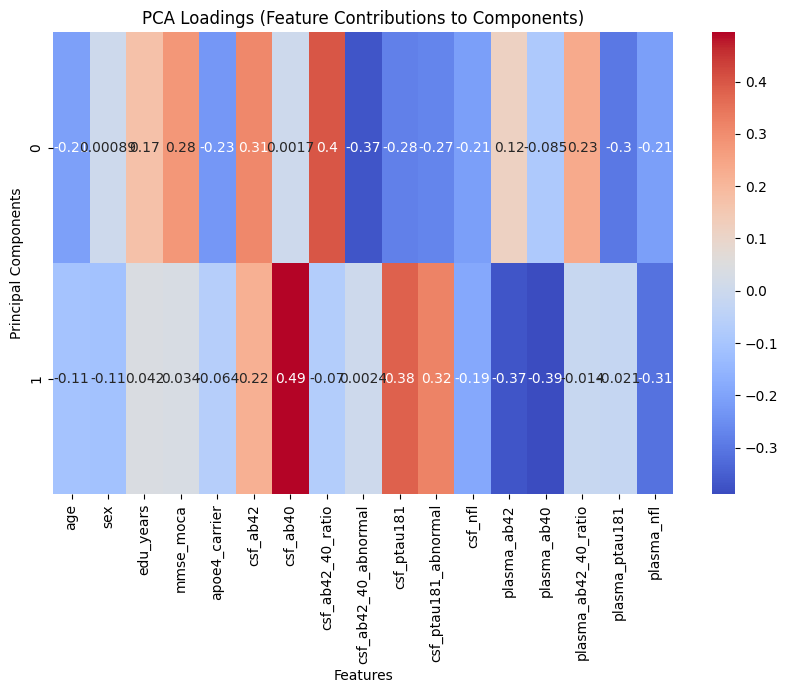

In [ ]:
import seaborn as sns

# Plot heatmap of the PCA loadings
plt.figure(figsize=(10, 6))
sns.heatmap(pca_loadings_df, cmap='coolwarm', annot=True, cbar=True)
plt.title('PCA Loadings (Feature Contributions to Components)')
plt.xlabel('Features')
plt.ylabel('Principal Components')
plt.show()


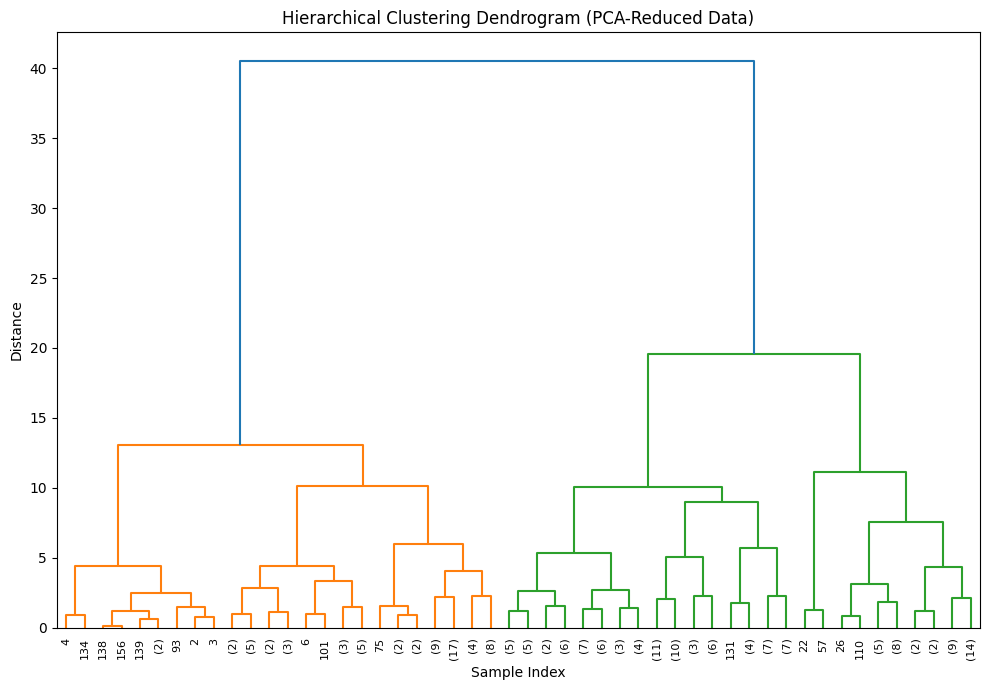

Silhouette Score (PCA-Reduced Data): 0.495


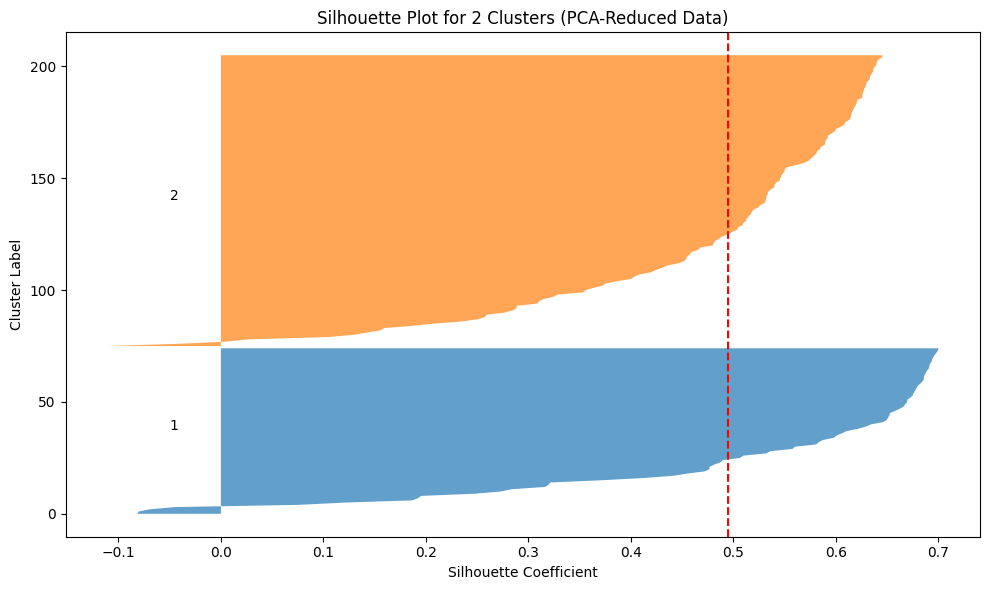

In [ ]:
# Step 3: Perform hierarchical clustering on the PCA-reduced data
linkage_matrix = linkage(df_pca, method='ward', metric='euclidean')

# Step 4: Plot the Dendrogram for hierarchical clustering
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix, truncate_mode='level', p=5)  # Show only the last p merges
plt.title('Hierarchical Clustering Dendrogram (PCA-Reduced Data)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# Step 5: Extract clusters using fcluster (based on a distance threshold)
t = 30  # You can adjust the threshold to define your clusters
clusters = fcluster(linkage_matrix, t=t, criterion='distance')

# Step 6: Calculate the silhouette score (based on the PCA-reduced data)
sil_score = silhouette_score(df_pca, clusters)
print(f'Silhouette Score (PCA-Reduced Data): {sil_score:.3f}')

# Step 7: Visualize silhouette scores for each cluster
silhouette_vals = silhouette_samples(df_pca, clusters)

plt.figure(figsize=(10, 6))
y_lower, y_upper = 0, 0
n_clusters = np.unique(clusters).shape[0]

for i in range(1, n_clusters + 1):
    # Aggregate silhouette scores for samples in cluster i
    ith_cluster_silhouette_vals = silhouette_vals[clusters == i]
    ith_cluster_silhouette_vals.sort()

    y_upper += len(ith_cluster_silhouette_vals)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_vals, alpha=0.7)

    plt.text(-0.05, y_lower + 0.5 * len(ith_cluster_silhouette_vals), str(i))
    y_lower = y_upper

plt.axvline(x=sil_score, color="red", linestyle="--")
plt.title(f'Silhouette Plot for {n_clusters} Clusters (PCA-Reduced Data)')
plt.xlabel('Silhouette Coefficient')
plt.ylabel('Cluster Label')
plt.tight_layout()

# Show the silhouette plot
plt.show()

Silhouette Score: 0.235
               age       sex  edu_years  mmse_moca  apoe4_carrier  csf_ab42  \
clusters                                                                      
1        -0.514345  0.048715   0.445214   0.707372      -0.617080  0.848414   
2         0.294604 -0.025967  -0.247693  -0.397641       0.353143 -0.486969   

          csf_ab40  csf_ab42_40_ratio  csf_ab42_40_abnormal  csf_ptau181  \
clusters                                                                   
1         0.008065           1.127275             -1.055088    -0.671397   
2         0.002270          -0.655197              0.616441     0.391798   

          csf_ptau181_abnormal   csf_nfl  plasma_ab42  plasma_ab40  \
clusters                                                             
1                    -0.742576 -0.389128     0.415891    -0.130960   
2                     0.431834  0.222079    -0.240904     0.065087   

          plasma_ab42_40_ratio  plasma_ptau181  plasma_nfl  
clusters    

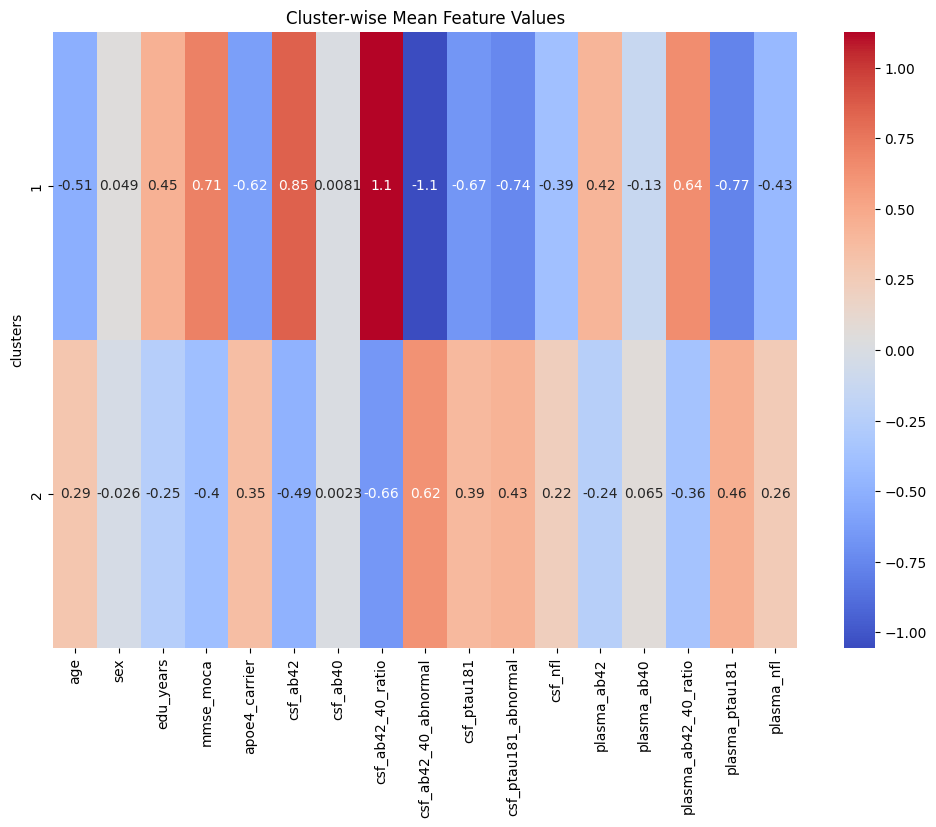

In [ ]:
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster

# Assuming you've already computed the linkage matrix from df_scaled_clean
# Ensure the lengths match between df_scaled_clean and clusters
if df_scaled_clean.shape[0] == len(clusters):
    # Create a new DataFrame to store the cleaned and scaled data along with cluster labels
    df_clustered = df_scaled_clean.copy()
    df_clustered['clusters'] = clusters

    # Compute the Silhouette Score
    sil_score = silhouette_score(df_scaled_clean, clusters)
    print(f'Silhouette Score: {sil_score:.3f}')

    # Analyze the clusters - Descriptive Statistics per Cluster
    cluster_summary = df_clustered.groupby('clusters').mean()
    print(cluster_summary)

    # Visualize Cluster Distributions using Heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(cluster_summary, annot=True, cmap='coolwarm')
    plt.title('Cluster-wise Mean Feature Values')
    plt.show()
else:
    print(f"Length mismatch: df_scaled_clean has {df_scaled_clean.shape[0]} rows, but clusters has {len(clusters)} labels.")


Silhouette Score: 0.147
               age       sex  edu_years  mmse_moca  apoe4_carrier  csf_ab42  \
clusters                                                                      
1        -0.745992 -0.125988   0.850182   0.753591      -0.990430  3.077798   
2        -0.478707  0.075593   0.382911   0.700262      -0.559641  0.505432   
3         0.155143 -0.021722  -0.258327  -0.387253       0.319975 -0.408047   
4         0.829358  0.881917  -0.509354  -1.151909       1.009662 -0.733196   
5         0.558021 -0.077993  -0.213204  -0.383242       0.390586 -0.638725   

          csf_ab40  csf_ab42_40_ratio  csf_ab42_40_abnormal  csf_ptau181  \
clusters                                                                   
1         1.749175           1.997995             -1.622214    -0.276535   
2        -0.259798           0.993318             -0.967838    -0.732145   
3         0.424992          -0.784121              0.616441     0.809492   
4        -1.228124          -0.208504     

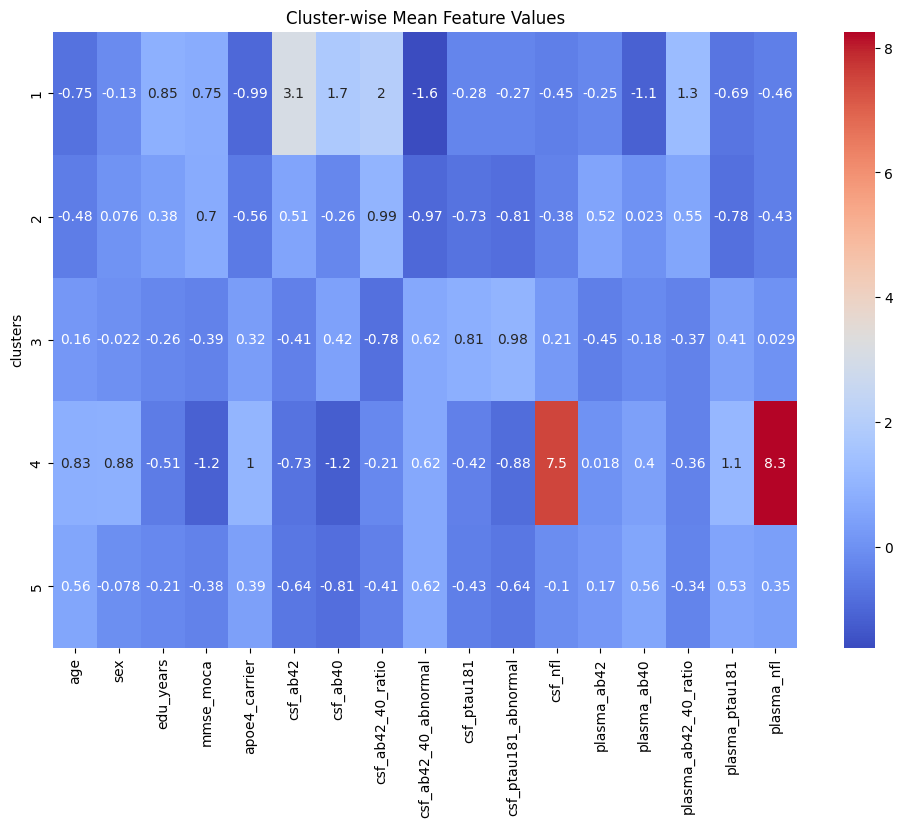

In [ ]:
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster

# Assuming you've already computed the linkage matrix from df_scaled_clean
# Extract clusters using fcluster (based on a distance threshold or number of clusters)
clusters = fcluster(linkage_matrix, t=5, criterion='maxclust')  # 't' is the threshold, adjust as needed

# Create a new DataFrame to store the cleaned and scaled data along with cluster labels
df_clustered = df_scaled_clean.copy()
df_clustered['clusters'] = clusters

# Compute the Silhouette Score
sil_score = silhouette_score(df_scaled_clean, clusters)
print(f'Silhouette Score: {sil_score:.3f}')

# Analyze the clusters - Descriptive Statistics per Cluster
cluster_summary = df_clustered.groupby('clusters').mean()
print(cluster_summary)

# Visualize Cluster Distributions using Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_summary, annot=True, cmap='coolwarm')
plt.title('Cluster-wise Mean Feature Values')
plt.show()

In [ ]:
from scipy.cluster.hierarchy import fcluster

# Cut the dendrogram at a specified distance threshold
t = 10  # Adjust the threshold based on your dendrogram
clusters = fcluster(linkage_matrix, t=t, criterion='distance')

# Print the cluster assignments
print("Cluster assignments:", clusters)


Cluster assignments: [5 5 1 1 1 3 2 7 5 5 5 5 5 2 2 2 3 7 2 4 7 5 6 4 7 4 7 4 5 7 5 4 4 4 3 5 5
 7 5 7 5 7 4 5 7 7 2 7 5 4 4 5 3 5 4 3 4 6 7 4 5 3 7 2 3 7 4 3 3 3 3 3 2 2
 2 3 3 2 3 3 1 3 3 3 3 3 3 3 3 3 5 3 7 1 7 2 7 4 5 2 7 2 4 3 7 7 7 5 7 5 7
 5 4 5 7 4 4 3 5 4 4 7 5 4 5 4 7 7 7 4 7 5 2 3 1 5 3 3 1 1 5 2 3 2 7 4 5 4
 2 5 7 7 7 5 4 2 1 7 3 5 4 3 3 5 3 5 4 7 5 7 5 2 2 4 3 4 3 2 4 5 3 7 5 7 5
 3 4 1 5 4 5 5 4 7 3 4 4 5 3 7 5 4 5 5 3 7]


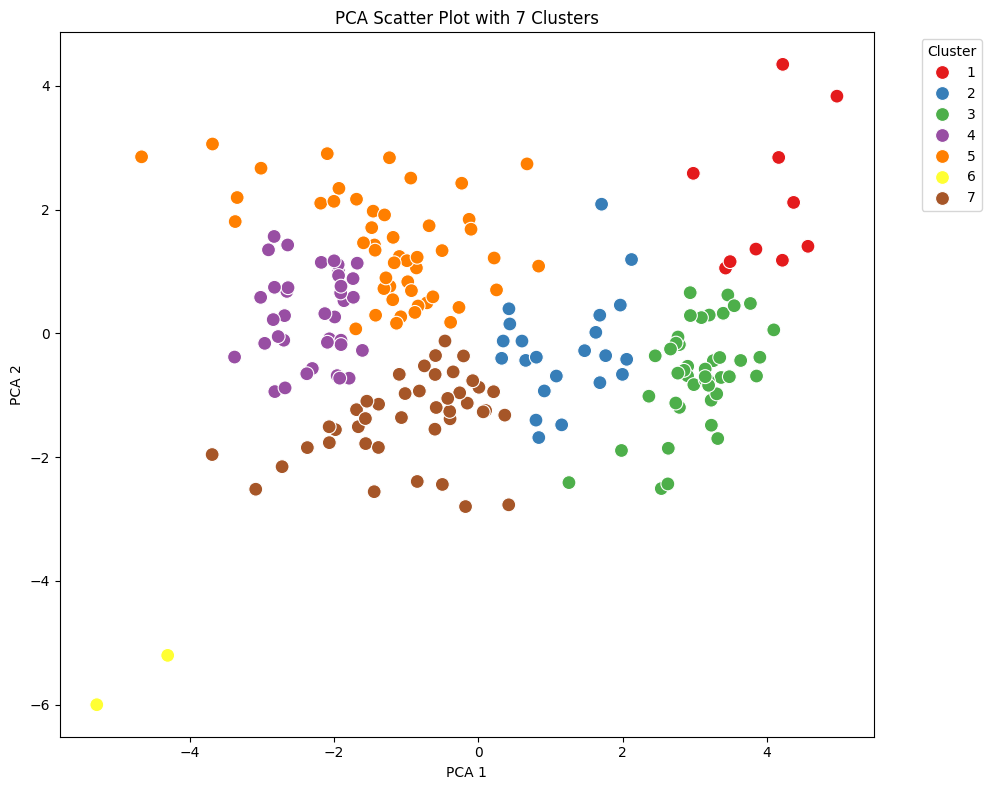

In [ ]:
# Assuming df_pca contains your PCA-reduced data (2 components)
df_pca_clustered = pd.DataFrame(df_pca, columns=['PCA1', 'PCA2'])
df_pca_clustered['clusters'] = clusters

# Plot the clusters in 2D
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='clusters', palette='Set1', data=df_pca_clustered, s=100)
plt.title(f'PCA Scatter Plot with {len(np.unique(clusters))} Clusters')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


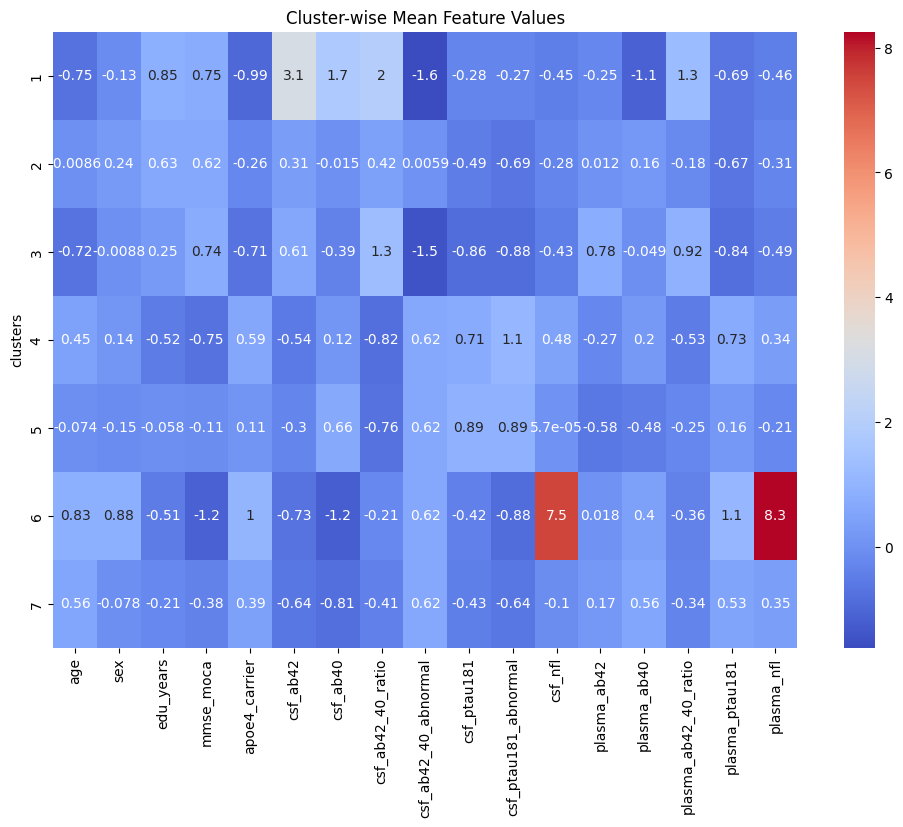

In [ ]:
# Create a DataFrame to analyze clusters
df_clustered = df_scaled_clean.copy()
df_clustered['clusters'] = clusters

# Compute the mean values for each cluster
cluster_means = df_clustered.groupby('clusters').mean()

# Plot a heatmap of the mean feature values for each cluster
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means, annot=True, cmap='coolwarm')
plt.title('Cluster-wise Mean Feature Values')
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score

# Calculate the silhouette score
sil_score = silhouette_score(df_scaled_clean, clusters)
print(f'Silhouette Score: {sil_score:.3f}')

Silhouette Score: 0.089


In [ ]:
import pandas as pd

# Ensure df_clustered contains the original variables and the cluster labels
df_clustered = df_scaled_clean.copy()  # Use the scaled clean data
df_clustered['clusters'] = clusters  # Add cluster labels

# Compute descriptive statistics for each cluster
cluster_summary = df_clustered.groupby('clusters').describe().transpose()

# Define a function to style the DataFrame
def style_table(df):
    # Apply gradient only to rows excluding 'count'
    non_count_rows = df.loc[~df.index.get_level_values(1).isin(['count'])]  # Exclude the 'count' row

    return (df.style
            .format("{:.2f}")  # Format to 2 decimal places
            .background_gradient(cmap='coolwarm', subset=pd.IndexSlice[non_count_rows.index, :])  # Exclude 'count'
            .set_properties(**{'border': '1px solid black', 'width': '120px'})  # Set borders
            .set_table_styles([{
                'selector': 'thead th',
                'props': [('background-color', '#404040'), ('color', 'white')]  # Header background color
            }])
            .set_caption("Cluster-wise Descriptive Statistics")  # Add caption/title
           )

# Style the summary table excluding 'count' from the gradient
styled_summary = style_table(cluster_summary)

# Display the styled table in a Jupyter notebook or save it to an HTML file
styled_summary

In [ ]:
# Export to CSV
cluster_summary.to_csv('hierarchical_AD-RIDDLE.csv')

# Export to Excel
cluster_summary.to_excel('hierarchical_AD-RIDDLE.xlsx')
